<a href="https://colab.research.google.com/github/hollyxue05/AMS-332-Physiological-Systems-Modeling/blob/main/spike_trains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poisson spike trains and basic measures of neural activity

In this computational project you will generate and analyze a dataset of 50 Poisson input spike trains. What follows is a series of simple coding exercises to visualize spike rasters and analyze their firing rate and other statistical properties.

## 1. Generate Poisson spike trains

Generate $N=50$ Poisson spike trains with rate $\lambda=10$ spikes/s, each lasting $T=5$ seconds. These will represent a dataset comprising recordings from the same neuron in $N=50$ trials of a fictitious experiment (one spike train for each trial). To generate the spike trains, generate first the inter-spike intervals (ISIs), and then obtain the spike times by cumulating the ISIs.
   Here is the outline of the procedure:

   - Use the fact that the ISIs of a Poisson spike train are exponentially distributed with parameter $\lambda$, i.e., $\operatorname{ISI}=-\log (\mathrm{u}) / \lambda$, where $\log ()$ is the natural $\operatorname{logarithm}$, and the random variable 'u' follows a uniform distribution between zero and one. The instruction `np.random.rand(n, 1)`  will generate $n$ such random deviates (where `np` stands for `numpy`).
   
   ***Note:*** Generate at least $2 \lambda T=100$ ISIs for each spike train, to make sure you have enough to cover $T$ seconds.

   - The ISIs are the differences between successive spike times, $\left\{\left(t_{2}-t_{1}\right),\left(t_{3}-t_{2}\right), \ldots,\left(t_{n}-t_{n-1}\right)\right\}$, where $t_{1}, t_{2}, \ldots, t_{n}$ are the spike times. Obtain the vector of spike times, $\mathbf{t}_{spk} \equiv\left\{t_{1}, t_{2}, \ldots, t_{n}\right\}$, by cumulating the ISIs:

     `tspk=np.cumsum(ISI)`,
     
     and the discard all the spike times that exceed $T=5$ seconds:

     `tspk[tspk > T] = np.nan`.

  - Repeat the above procedure $N=50$ times, once for each spike train.

In [ ]:
# Generate Poisson spike trains - insert your code here
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

# Initialize a list to store spike times for each trial
all_spike_trains = []

for i in range(N):
    # Generate random variables 'u' from a uniform distribution (0, 1)
    u = np.random.rand(num_isis)

    # Calculate ISIs using the exponential distribution formula: ISI = -log(u) / lambda
    isis = -np.log(u) / lambda_rate

    # Cumulate ISIs to get absolute spike times
    tspk = np.cumsum(isis)

    # Discard spike times that exceed T = 5 seconds
    tspk = tspk[tspk <= T]

    all_spike_trains.append(tspk)

## 2. Raster plot

Perform a raster plot of these $N$ spike trains. This is a plot showing each spike train on a different horizontal line (from 1 to $N$ ), with the spike times on each line as a sequence of dots, each line stacked above the previous one (see Box 1 for help). Label the horizontal axis as 'time' (from zero to $T$ sec) and the vertical axis as 'trial number' (from 1 to $N$ ).

Once this is done, you can visualize all $N$ spike trains in a raster plot:

`plt.plot(tspk, range(1, N + 1), '.k') # raster plot`

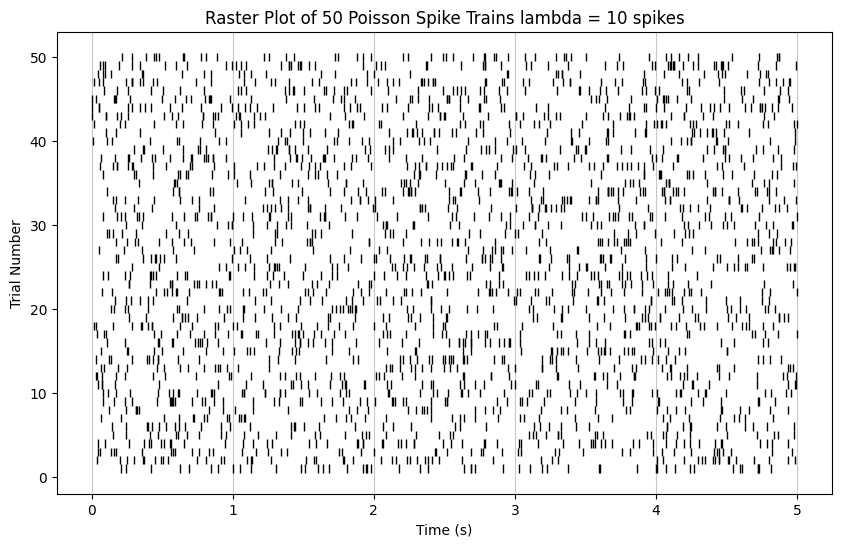

In [ ]:
# raster plot - insert your code here
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

# Initialize a list to store spike times for each trial
all_spike_trains = []

for i in range(N):
    # Generate random variables 'u' from a uniform distribution (0, 1)
    u = np.random.rand(num_isis)

    # Calculate ISIs using the exponential distribution formula: ISI = -log(u) / lambda
    isis = -np.log(u) / lambda_rate

    # Cumulate ISIs to get absolute spike times
    tspk = np.cumsum(isis)

    # Discard spike times that exceed T = 5 seconds
    tspk = tspk[tspk <= T]

    all_spike_trains.append(tspk)

# Raster plot
plt.figure(figsize=(10, 6))
for trial_idx, spikes in enumerate(all_spike_trains):
    # Plot each spike as a vertical line (a "tick")
    plt.vlines(spikes, trial_idx + 0.5, trial_idx + 1.5, color='black', linewidth=1)

plt.xlabel('Time (s)')
plt.ylabel('Trial Number')
plt.title(fr'Raster Plot of {N} Poisson Spike Trains lambda = {lambda_rate} spikes')
plt.grid(axis='x', alpha=0.7)
plt.show()

## 3. Firing rate

Calculate the average firing rate across trials for the whole simulation interval ( $T$ sec) as

$$
\begin{equation*}
f=\frac{\text { number of total spikes across trials }}{N \cdot T} . \tag{1}
\end{equation*}
$$

Confirm that your estimated firing rate $f$ is very close to the theoretical firing rate $\lambda$.

In [ ]:
# firing rate - insert your code here
import numpy as np
import matplotlib.pyplot as plt

# 1. Count total spikes across all N trials
# Since each element in all_spike_trains is an array of spike times,
# len() gives the count for that trial.
total_spikes = sum(len(spikes) for spikes in all_spike_trains)

# 2. Calculate the estimated firing rate f
# Formula: f = total_spikes / (N * T)
estimated_f = total_spikes / (N * T)

print(f"Total number of spikes: {total_spikes}")
print(f"Estimated firing rate (f): {estimated_f:.2f} spikes/s")
print(f"Theoretical firing rate (lambda): {lambda_rate} spikes/s")

Total number of spikes: 2492
Estimated firing rate (f): 9.97 spikes/s
Theoretical firing rate (lambda): 10 spikes/s


## 4. Peri-stimulus time histogram (PSTH)

Next, divide the total time $T$ in $N_{b}=T / \Delta t$ bins, each of length $\Delta t=0.2 \mathrm{~s}$. Calculate the firing rate in each bin, i.e., in the first time bin $T_{1}=[0,0.2]$, in the second time bin $T_{2}=[0.2,0.4]$, and so on, until the firing rate in the last time bin $T_{25}=[4.8,5.0]$ has also been determined. This will give you the set of firing rates

$$
\begin{equation*}
f\left(T_{i}\right)=\frac{\text { number of total spikes in } T_{i} \text { across trials }}{N \cdot \Delta t} . \tag{2}
\end{equation*}
$$

​	Plot $f\left(T_{i}\right)$ as a function of the middle points $t_{i}^{*}$ of time bins $T_{i}$ (for example, the middle point of time bin $T_{1}=[0,0.2]$ is 	  	$t_{1}^{*}=\frac{1}{2}(0+0.2)=0.1 \mathrm{~s}$).

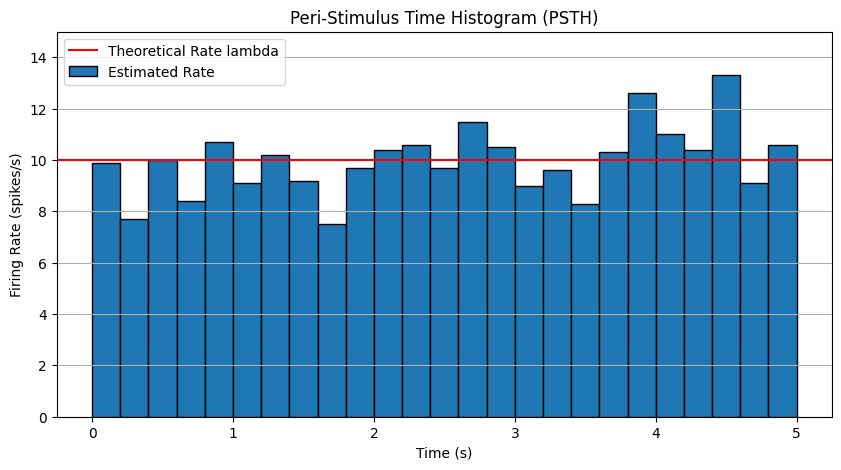

In [ ]:
# PSTH - insert your code here
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

# Initialize a list to store spike times for each trial
all_spike_trains = []

for i in range(N):
    # Generate random variables 'u' from a uniform distribution (0, 1)
    u = np.random.rand(num_isis)

    # Calculate ISIs using the exponential distribution formula: ISI = -log(u) / lambda
    isis = -np.log(u) / lambda_rate

    # Cumulate ISIs to get absolute spike times
    tspk = np.cumsum(isis)

    # Discard spike times that exceed T = 5 seconds
    tspk = tspk[tspk <= T]

    all_spike_trains.append(tspk)



# Parameters for binning
delta_t = 0.2
bins = np.arange(0, T + delta_t, delta_t)  # [0, 0.2, 0.4, ..., 5.0]
num_bins = len(bins) - 1

all_spikes_flat = np.concatenate(all_spike_trains)

# Use np.histogram to count total spikes in each bin across all trials
counts, bin_edges = np.histogram(all_spikes_flat, bins=bins)

# Calculate the firing rate for each bin f(Ti)
bin_firing_rates = counts / (N * delta_t)

# Calculate middle points t* for each bin
bin_middles = bins[:-1] + delta_t / 2

# Plot
plt.figure(figsize=(10, 5))
plt.grid(axis='y')
plt.bar(bin_middles, bin_firing_rates, width=delta_t, edgecolor='black', label='Estimated Rate')
plt.axhline(y=lambda_rate, color='red', label='Theoretical Rate lambda')

plt.xlabel('Time (s)')
plt.ylabel('Firing Rate (spikes/s)')
plt.title('Peri-Stimulus Time Histogram (PSTH)')
plt.legend()
plt.ylim(0, lambda_rate + 5)
plt.show()

## 5. Coefficient of variability (CV)

Compute the coefficient of variability (CV) of the inter-spike intervals (ISIs) in each trial. The CV quantifies the variability of the ISIs in each trial and is defined as the ratio of the standard deviation to the mean of the ISIs: in each trial $k=1, \ldots, N$,

$$
\begin{equation*}
C V_{k}=\frac{\operatorname{StDev}(\mathrm{ISI})_{k}}{\operatorname{Mean}(\mathrm{ISI})_{k}} . \tag{3}
\end{equation*}
$$

Plot $\mathrm{CV}_{k}$ as a function of trial number $k$. ***Note***: Given the vector of spike times $\mathbf{t}_{spk}=\left\{t_{1}, t_{2}, \ldots, t_{n}\right\}$, the ISIs can be conveniently obtained as `ISI=np.diff(tspk)`.



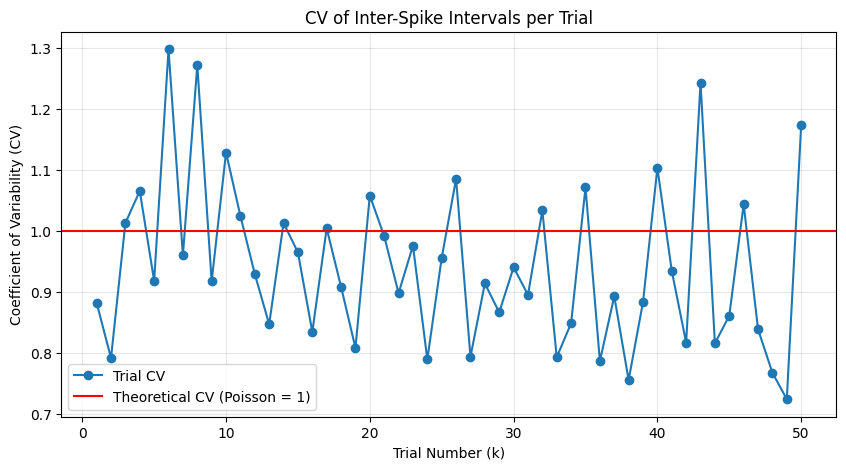

Average CV across all trials: 0.9428


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

# Initialize a list to store spike times for each trial
all_spike_trains = []

for i in range(N):
    # Generate random variables 'u' from a uniform distribution (0, 1)
    u = np.random.rand(num_isis)

    # Calculate ISIs using the exponential distribution formula: ISI = -log(u) / lambda
    isis = -np.log(u) / lambda_rate

    # Cumulate ISIs to get absolute spike times
    tspk = np.cumsum(isis)

    # Discard spike times that exceed T = 5 seconds
    tspk = tspk[tspk <= T]

    all_spike_trains.append(tspk)



# Initialize an array to store CV for each trial
cv_values = np.zeros(N)

for k in range(N):
    # Get the spike times for the current trial
    tspk = all_spike_trains[k]

    # Calculate ISIs from the spike times
    # np.diff computes the difference between consecutive elements
    isis = np.diff(tspk)

    # Calculate CV = StDev(ISI) / Mean(ISI)
    # We use a small check to ensure there are at least 2 spikes to calculate an interval
    if len(isis) > 0:
        cv_values[k] = np.std(isis) / np.mean(isis)
    else:
        cv_values[k] = 0

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, N + 1), cv_values, 'o-', label='Trial CV')
plt.axhline(y=1.0, color='red', label='Theoretical CV (Poisson = 1)')

plt.xlabel('Trial Number (k)')
plt.ylabel('Coefficient of Variability (CV)')
plt.title('CV of Inter-Spike Intervals per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the average CV across all trials
print(f"Average CV across all trials: {np.mean(cv_values):.4f}")

​Next, average $\mathrm{CV}_{k}$ across trials,
$$
\begin{equation*}
\langle C V\rangle=N^{-1} \sum_{k=1}^{N} C V_{k}, \tag{4}
\end{equation*}
$$

​	and check that $\langle C V\rangle \approx 1$, the theoretical CV of Poisson spike trains. ***Note:*** Mean, 	standard deviation and variance of a vector $\mathbf{x}$ can be obtained as `np.mean(x)`, `np.std(x)`, and `np.var(x)`, respectively.
​

In [ ]:
# insert your code here
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

# Initialize a list to store spike times for each trial
all_spike_trains = []

for i in range(N):
    # Generate random variables 'u' from a uniform distribution (0, 1)
    u = np.random.rand(num_isis)

    # Calculate ISIs using the exponential distribution formula: ISI = -log(u) / lambda
    isis = -np.log(u) / lambda_rate

    # Cumulate ISIs to get absolute spike times
    tspk = np.cumsum(isis)

    # Discard spike times that exceed T = 5 seconds
    tspk = tspk[tspk <= T]

    all_spike_trains.append(tspk)



# Initialize an array to store CV for each trial
cv_values = np.zeros(N)

for k in range(N):
    # Get the spike times for the current trial
    tspk = all_spike_trains[k]

    # Calculate ISIs from the spike times
    # np.diff computes the difference between consecutive elements
    isis = np.diff(tspk)

    # Calculate CV = StDev(ISI) / Mean(ISI)
    # We use a small check to ensure there are at least 2 spikes to calculate an interval
    if len(isis) > 0:
        cv_values[k] = np.std(isis) / np.mean(isis)
    else:
        cv_values[k] = 0

# Calculate the average CV across all trials
average_cv = np.mean(cv_values)

print(f"Number of trials (N): {N}")
print(f"Calculated average CV: {average_cv:.4f}")
print(f"Theoretical CV for Poisson: 1.0")

Number of trials (N): 50
Calculated average CV: 0.9639
Theoretical CV for Poisson: 1.0


## 6. Fano factor (FF)

Quantify the trial-to-trial variability of this dataset by computing the so-called Fano Factor (FF). The FF is defined as the ratio of the variance to the mean (across trials) of the spike count:

$$
\begin{equation*}
F F=\frac{\operatorname{Var}_{\text {trials }}(\text { count })}{\text { Mean }_{\text {trials }}(\text { count })} \tag{5}
\end{equation*}
$$

In [ ]:
# FF - insert your code here
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

# Initialize a list to store spike times for each trial
all_spike_trains = []

for i in range(N):
    # Generate random variables 'u' from a uniform distribution (0, 1)
    u = np.random.rand(num_isis)

    # Calculate ISIs using the exponential distribution formula: ISI = -log(u) / lambda
    isis = -np.log(u) / lambda_rate

    # Cumulate ISIs to get absolute spike times
    tspk = np.cumsum(isis)

    # Discard spike times that exceed T = 5 seconds
    tspk = tspk[tspk <= T]

    all_spike_trains.append(tspk)


# Calculate the spike count for each trial
# We can use the length of each entry in our list of spike trains
spike_counts = np.array([len(spikes) for spikes in all_spike_trains])

# Compute the variance and the mean across trials
variance_counts = np.var(spike_counts)
mean_counts = np.mean(spike_counts)

# Calculate Fano Factor (FF)
fano_factor = variance_counts / mean_counts

print(f"Mean spike count: {mean_counts:.2f}")
print(f"Variance of spike counts: {variance_counts:.2f}")
print(f"Experimental Fano Factor (FF): {fano_factor:.4f}")

Mean spike count: 49.82
Variance of spike counts: 48.71
Experimental Fano Factor (FF): 0.9777



## Question

Theoretically, for Poisson spike trains $\mathrm{FF}=1$. Is that confirmed (at least approximately) in your data? (Run the code several times to estimate an average value for FF; single samples don't tell us much).

In [ ]:
# insert your code here
import numpy as np
import matplotlib.pyplot as plt

# Number of simulations to run
num_simulations = 10
ff_results = np.zeros(num_simulations)

print(f"Running {num_simulations} simulations")

for s in range(num_simulations):
    # 1. Generate a new dataset of N spike trains
    current_sim_counts = []

    for i in range(N):
        # Generate enough ISIs and cumulate them
        u = np.random.rand(num_isis)
        isis = -np.log(u) / lambda_rate
        tspk = np.cumsum(isis)

        # Count spikes within the duration T
        count = np.sum(tspk <= T)
        current_sim_counts.append(count)

    # 2. Convert to array and calculate FF for this simulation
    counts_array = np.array(current_sim_counts)
    ff_results[s] = np.var(counts_array) / np.mean(counts_array)

    print(f"Sim {s+1}: FF = {ff_results[s]:.4f}")

# Final summary
print(f"Mean FF over all simulations: {np.mean(ff_results):.4f}")

Running 10 simulations
Sim 1: FF = 0.6414
Sim 2: FF = 0.9257
Sim 3: FF = 1.0337
Sim 4: FF = 0.7089
Sim 5: FF = 1.4584
Sim 6: FF = 1.0753
Sim 7: FF = 0.9780
Sim 8: FF = 0.8952
Sim 9: FF = 0.9775
Sim 10: FF = 1.5633
Mean FF over all simulations: 1.0257


After running the simulation 10 times and calculating the FF each time, the data supports the theoretical FF value being 1. I also tried increasing the number of simulations to 30, which furthur brought the average FF closer to 1. This is thanks to the law of large numbers which states that as the number of independent trials increase, the calcuated statistic (mean in this case) gets closer and closer to the theoretical value.  

## 7. CV and FF vs T

Repeat Exercises 5. and 6. for increasing interval durations $T$ (in seconds). Use

$$
\begin{equation*}
T=\{10,100,200,400,800,1600,3200,6400, 20000\} \tag{6}
\end{equation*}
$$

​	For each value of $T$, take the CV of a **single** spike train (for example, the first) and the FF of the set of 50 spike trains. Plot both the CV and the FF values as a function of $T$ in the same plot (note: do NOT plot the spike rasters!).

*Note*: Use a log scale for the x-axis using `plt.xscale('log')` and set the limits of the y-axis to e.g. [0 2] to be able to compare the results for different values of $N$:
`plt.ylim(0,2)`


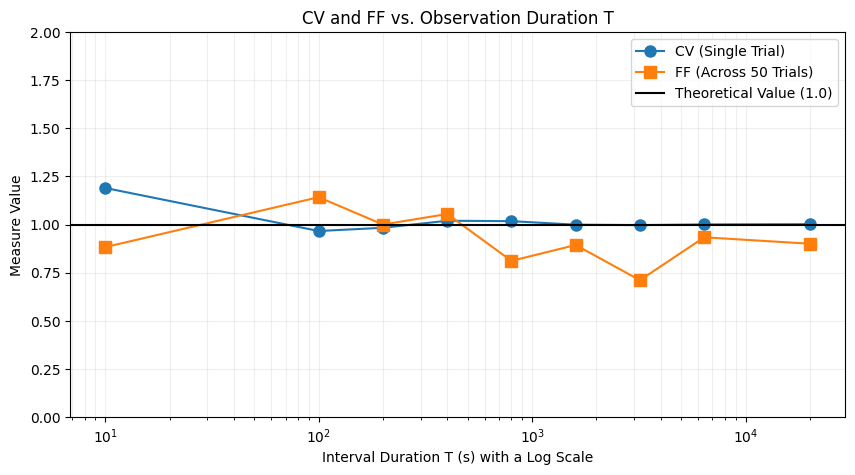

In [ ]:
# insert your code here
# Array of durations T to test
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50          # Number of trials
lambda_rate = 10 # Spikes per second
T = 5           # Duration in seconds
num_isis = 2 * lambda_rate * T  # Ensuring enough ISIs to cover T seconds

T_values = [10, 100, 200, 400, 800, 1600, 3200, 6400, 20000]

cv_results = []
ff_results = []

for T_val in T_values:
    # Generate N trials for this specific T
    spike_counts = []
    first_trial_isis = None

    for i in range(N):
        # Generate enough ISIs for the current duration
        n_isis = int(1.5 * lambda_rate * T_val)
        u = np.random.rand(n_isis)
        isis = -np.log(u) / lambda_rate
        tspk = np.cumsum(isis)

        # Trim spikes to [0, T_val]
        spikes_in_T = tspk[tspk <= T_val]
        spike_counts.append(len(spikes_in_T))

        # Save the ISIs of the first trial for CV calculation
        if i == 0:
            first_trial_isis = np.diff(spikes_in_T)

    # Calculate CV of the single (first) spike train
    cv_val = np.std(first_trial_isis) / np.mean(first_trial_isis)
    cv_results.append(cv_val)

    # Calculate FF of the set of 50 spike trains
    counts_array = np.array(spike_counts)
    ff_val = np.var(counts_array) / np.mean(counts_array)
    ff_results.append(ff_val)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(T_values, cv_results, 'o-', label='CV (Single Trial)', markersize=8)
plt.plot(T_values, ff_results, 's-', label='FF (Across 50 Trials)', markersize=8)
plt.axhline(y=1.0, color='black', label='Theoretical Value (1.0)')

plt.xscale('log')
plt.ylim(0, 2)
plt.xlabel('Interval Duration T (s) with a Log Scale')
plt.ylabel('Measure Value')
plt.title('CV and FF vs. Observation Duration T')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## Questions

(i) Does the CV visibly converge to 1 as $T$ increases? Does the FF? (You may want to run your code a few times before committing to a conclusion).

(ii) What could you do to reduce the variability of the FF?

The CV reliably looks to converge to 1 as T increases. However, FF appears to have a lot of diverse variation that doesn't look to have a relationship with increasing T.

In order to reduce the variability of FF, the number of trials should also be increased. Doing this would utilize the law of large numbers which states that as the number of independent trials increase, the calcuated statistic gets closer and closer to the theoretical value. Therefore, FF should get closer to its theoretical value of 1 after N is increased.

